In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv('mapped.bed', sep='\t', header=None)
print(f"Data: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())


Data: 1361453 rows and 13 columns


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90838.0,91006.0,IH02_00.pairs@15152,168.0,+
1,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90846.0,90998.0,IH02_04.pairs@4163,152.0,+
2,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90851.0,91000.0,IH02_04.pairs@4164,149.0,+
3,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90850.0,91014.0,IH02_00.pairs@15153,164.0,+
4,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90900.0,90965.0,IH02_00.pairs@15164,65.0,+


In [10]:
def calc_xyz(df):
    # computing center positions
    df['C1'] = (df[2] + df[3]) / 2
    df['C2'] = (df[8] + df[9]) / 2
    df['X'] = (df['C2'] - df['C1']).round().fillna(0).astype(int)
    df['Y'] = df[9] - df[8]
    xyz = df.groupby(['X', 'Y']).size().reset_index(name='Z')
    return xyz

xyz = calc_xyz(df)
print("\nSample of calculated X, Y, Z values:")
display(xyz.head())



Sample of calculated X, Y, Z values:


,X,Y,Z
0,-509,44.0,2
1,-509,46.0,1
2,-509,48.0,3
3,-509,50.0,8
4,-509,52.0,8


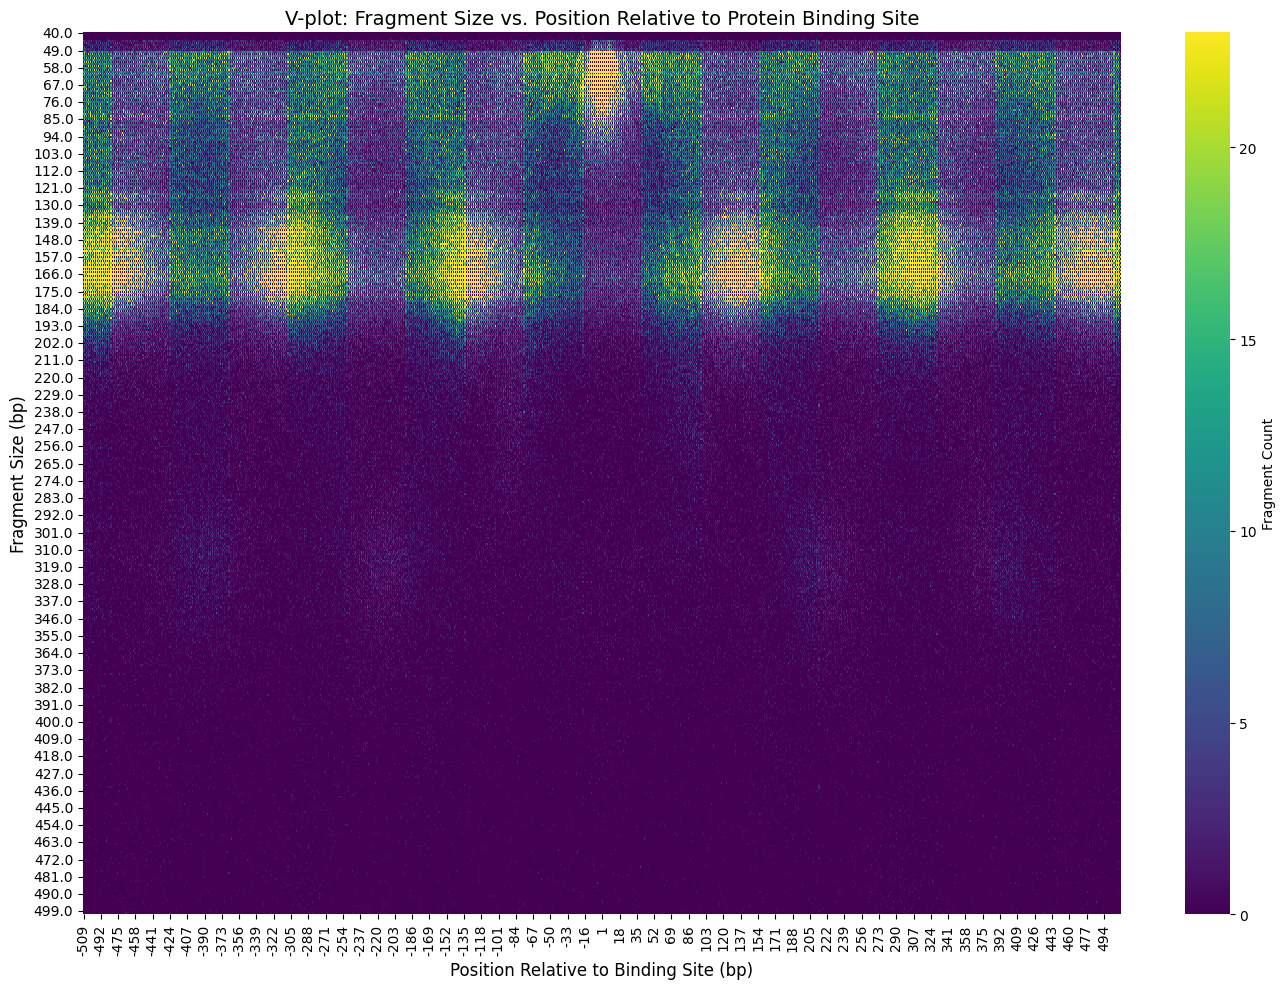

In [11]:
def vplot(xyz, out_file=None):
    # generating V-plot
    pv = xyz.pivot_table(values='Z', index='Y', columns='X', fill_value=0)
    plt.figure(figsize=(14, 10))
    sns.heatmap(pv, cmap='viridis', robust=True)
    plt.xlabel('Position Relative to Binding Site (bp)', fontsize=12)
    plt.ylabel('Fragment Size (bp)', fontsize=12)
    plt.title('V-plot: Fragment Size vs. Position Relative to Protein Binding Site', fontsize=14)
    plt.gca().collections[0].colorbar.set_label('Fragment Count', fontsize=10)
    plt.tight_layout()
    if out_file:
        plt.savefig(out_file)
    plt.show()

vplot(xyz)
